# Computational Tools for Climate Science - Project 2026
---
**Group 2 - Chaac**

Authors: *Abiyo Gladys, Alex Blackmer, Caroline Roper, Han Nguyen, Negli Gallardo, Sheila Aguilar Palpa*

Date: *July 13-24th*

---

This project explores the relationship between precipitation and crop production in Southeast Asia. Specifically, we tie the Standardized Precipitation Index (SPI) derived from Climate Hazards Group InfraRed Precipitation with Station data (CHIRPS) with cereal production yield anomalies sourced from the Food and Agriculture Organization (FAO). This study considers two domains in Southeast Asia; the mainland (Monsoon Climate Region - MCR) and maritime (Equatorial Climate Region - ECR), focusing on the countries of Vietnam and Indonesia respectively.

In [266]:
# Install packages not included in base environment
!pip install cartopy
!pip install gdown
!pip install xclim

In [267]:
# Imports
import os
# Scientific data packages
import numpy as np
import xarray as xr
import pandas as pd
import datetime
# Plotting libraries
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
# Climate index package
import xclim

---
# Data Management
## Mount Google Drive
First step is to mount the Google Drive fonder containing group project data

In [268]:
# Mount Google Drive project data path
from google.colab import drive
drive.mount('/content/drive')
path_gd =  "/content/drive/MyDrive/Data/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Downloading data
This is a helper function for downloading data

---

In [269]:
import tempfile
import pooch
def pooch_load(filelocation=None, filename=None, processor=None):
    shared_location = './data'  # This is where we want to store the data
    user_temp_cache = tempfile.gettempdir()
    # Ensure the shared_location directory exists
    os.makedirs(shared_location, exist_ok=True)
    target_path = os.path.join(shared_location, filename)
    if os.path.exists(target_path):
        file = target_path
    else:
        # Download the file directly to the shared_location
        # Explicitly specify 'path' to ensure it goes to ./data and not the hidden cache
        file = pooch.retrieve(
            filelocation,
            known_hash=None,
            path=shared_location,
            fname=filename,
            processor=processor
        )
    return file

---
## Load Datasets
This section loads the country masks, precipitation, and cereal production data used for analysis

### Precipitation

In [270]:
path_gd = '/content/drive/MyDrive/Group Project Folder/Data/'

In [271]:
precip_ds = xr.open_dataset(path_gd+ "chirps_sel.nc")
precip_ds

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 546, latitude: 900, longitude: 1200)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2026-06-01
  * latitude   (latitude) float32 4kB -19.98 -19.92 -19.88 ... 24.88 24.92 24.97
  * longitude  (longitude) float32 5kB 90.02 90.08 90.12 ... 149.9 149.9 150.0
Data variables:
    precip     (time, latitude, longitude) float32 2GB ...
Attributes: (12/14)
    Conventions:       CF-1.6
    title:             CHIRPS Version 3.0
    history:           created by Climate Hazards Center
    version:           Version 3.0
    data_created:      2026-07-14
    creator_name:      Pete Peterson
    ...                ...
    documentation:     http://pubs.usgs.gov/ds/832/
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    acknowledgements:  The Climate Hazards Center InfraRed Precipitation with...
    ftp_url:           ftp://chg-ftpout.geog.ucsb.edu/pub/chg/products/CHIRPS...
    website:           http://chg.geog.ucsb.edu/data/chirps/index.html
    faq:               http://chg-wiki.geog.ucsb.edu/wiki/CHIRPS_FAQ

### Country Mask

In [272]:
country_mask = xr.open_dataset(path_gd + 'CountryMask/NetCDF/CountryMergedNC.nc')
country_mask = country_mask.rename({"lat": "latitude", "lon": "longitude"})

country_mask = country_mask["country_mask"].interp(
    latitude=precip_ds.latitude,
    longitude=precip_ds.longitude,
    method="nearest"
)

### Cereal Production

In [273]:
cereal_df = pd.read_csv(path_gd + "data_cereal_land.csv", header=0, skiprows=4 )

### Population Data

In [274]:
pop_df = pd.read_csv(path_gd + 'population_estimations_WorldBank.csv', skiprows=4, sep=';')

countries_pop = ['Indonesia', 'Viet Nam']
years = [str(year) for year in range(1981, 2024)]
columns_to_keep = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'] + years

pop_df_filtered = pop_df[pop_df['Country Name'].isin(countries_pop)]
pop_df_filtered = pop_df_filtered[columns_to_keep]

pop_df = pop_df_filtered.copy() # Assign the filtered DataFrame back to pop_df
pop_df

,Country Name,Country Code,Indicator Name,Indicator Code,1981,1982,1983,1984,1985,1986,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
105,Indonesia,IDN,"Population, total",SP.POP.TOTL,152485035.0,156052152.0,159651381.0,163251124.0,166776185.0,170175065.0,...,258877399.0,261799249.0,264627418.0,267346658.0,269951846.0,272489381.0,274814866.0,276758053.0,278830529.0,281190067.0
256,Viet Nam,VNM,"Population, total",SP.POP.TOTL,53738141.0,55011289.0,56337921.0,57706067.0,59060622.0,60347048.0,...,91679578.0,92823254.0,94000117.0,95176977.0,96237319.0,97173776.0,98079191.0,98935098.0,99680655.0,100352192.0


---
## Subset Precipitation Data By Country

In [275]:
# Mask each contry area and drop the NaNs
precip_ind = precip_ds.precip.where(country_mask == 1, drop=True)
precip_viet = precip_ds.precip.where(country_mask == 2, drop=True)

---
# Analysis

## SPI Calculation
Standardized precipitation index is calculated individually for Vietnam and Indonesia

In [276]:
precip_viet_1d = precip_viet.mean(dim=["latitude", "longitude"])
spi_1m_viet = xclim.indicators.atmos.standardized_precipitation_index(pr=precip_viet_1d, freq='MS', window=1)
spi_6m_viet = xclim.indicators.atmos.standardized_precipitation_index(pr=precip_viet_1d, freq='MS', window=6)
spi_12m_viet = xclim.indicators.atmos.standardized_precipitation_index(pr=precip_viet_1d, freq='MS', window=12)

/usr/local/lib/python3.12/dist-packages/xclim/core/cfchecks.py:77: UserWarning: Variable does not have a `cell_methods` attribute.
  _check_cell_methods(getattr(vardata, "cell_methods", None), data["cell_methods"])
/usr/local/lib/python3.12/dist-packages/xclim/core/cfchecks.py:79: UserWarning: Variable has a non-conforming standard_name: Got `convective precipitation rate`, expected `['precipitation_flux']`
  check_valid(vardata, "standard_name", data["standard_name"])
/usr/local/lib/python3.12/dist-packages/xclim/core/cfchecks.py:77: UserWarning: Variable does not have a `cell_methods` attribute.
  _check_cell_methods(getattr(vardata, "cell_methods", None), data["cell_methods"])
/usr/local/lib/python3.12/dist-packages/xclim/core/cfchecks.py:79: UserWarning: Variable has a non-conforming standard_name: Got `convective precipitation rate`, expected `['precipitation_flux']`
  check_valid(vardata, "standard_name", data["standard_name"])
/usr/local/lib/python3.12/dist-packages/xclim/core/c

In [277]:
precip_ind_1d = precip_ind.mean(dim=["latitude", "longitude"])
spi_1m_ind = xclim.indicators.atmos.standardized_precipitation_index(pr=precip_ind_1d, freq='MS', window=1)
spi_6m_ind = xclim.indicators.atmos.standardized_precipitation_index(pr=precip_ind_1d, freq='MS', window=6)
spi_12m_ind = xclim.indicators.atmos.standardized_precipitation_index(pr=precip_ind_1d, freq='MS', window=12)

/usr/local/lib/python3.12/dist-packages/xclim/core/cfchecks.py:77: UserWarning: Variable does not have a `cell_methods` attribute.
  _check_cell_methods(getattr(vardata, "cell_methods", None), data["cell_methods"])
/usr/local/lib/python3.12/dist-packages/xclim/core/cfchecks.py:79: UserWarning: Variable has a non-conforming standard_name: Got `convective precipitation rate`, expected `['precipitation_flux']`
  check_valid(vardata, "standard_name", data["standard_name"])
/usr/local/lib/python3.12/dist-packages/xclim/core/cfchecks.py:77: UserWarning: Variable does not have a `cell_methods` attribute.
  _check_cell_methods(getattr(vardata, "cell_methods", None), data["cell_methods"])
/usr/local/lib/python3.12/dist-packages/xclim/core/cfchecks.py:79: UserWarning: Variable has a non-conforming standard_name: Got `convective precipitation rate`, expected `['precipitation_flux']`
  check_valid(vardata, "standard_name", data["standard_name"])
/usr/local/lib/python3.12/dist-packages/xclim/core/c

In [278]:
def monthly_severity_per_year(x):
  '''takes x, an xarray.DataArray with variable 'spi' monthly and outputs a pandas dataframe of the number of months at each severity level per year'''
  yearly = x.groupby('time.year').map(lambda x: x.groupby_bins(x, bins=[-np.inf, -2, -1.5, -1, 0, np.inf]).count()).fillna(0)
  yearly = yearly.to_dataframe().pivot_table(index = 'year', columns = 'spi_bins')
  yearly.columns = yearly.columns.droplevel(0)
  new_column_names = ['Extreme', 'Severe', 'Moderate', 'Mild', 'No Drought']
  yearly.columns = new_column_names
  return yearly

In [279]:
def categorize_spi(spi_data_array):
  """
  Categorizes SPI values into drought severity levels.

  Takes an xarray DataArray containing 12m SPI values with a 'time' coordinate.

  Returns a pandas DataFrame with the annual 'spi' and its 'category'
  """
  spi_12m_annual = spi_data_array.resample(time='1YE').last()
  spi_12m_annual_pd = spi_12m_annual.to_pandas()
  spi_12m_annual_pd.index = spi_12m_annual_pd.index.year
  spi_12m_annual_pd.index.name = 'year'
  spi_values = spi_12m_annual_pd.rename('SPI Value')

  # Define bins and labels for drought severity
  bins = [-np.inf, -2.0, -1.5, -1.0, 0, np.inf]
  labels = ['Extreme Drought', 'Severe Drought', 'Moderate Drought', 'Mild Drought', 'No Drought']

  # Categorize SPI values
  spi_category = pd.cut(spi_values, bins=bins, labels=labels, right=False)

  # Create a DataFrame from the results
  result_df = pd.DataFrame({
      'spi': spi_values,
      'category': spi_category
  })

  return result_df

In [280]:
per_year_months_at_severity_level_viet = monthly_severity_per_year(spi_1m_viet)

In [281]:
per_year_months_at_severity_level_indonesia = monthly_severity_per_year(spi_1m_ind)

In [282]:
spi_yearly_viet = categorize_spi(spi_12m_viet)
spi_yearly_indonesia = categorize_spi(spi_12m_ind)

In [283]:
annual_spi_viet = per_year_months_at_severity_level_viet.join(spi_yearly_viet)
#annual_spi_viet.to_csv(path_gd + 'annual_spi_vietnam.csv')

In [284]:
annual_spi_indonesia = per_year_months_at_severity_level_indonesia.join(spi_yearly_indonesia)
#annual_spi_indonesia.to_csv(path_gd + 'annual_spi_indonesia.csv')

## Cereal Anomalies

In [285]:
# #Importing data
# from google.colab import drive
# drive.mount('/content/drive')
# path =  "/content/drive/MyDrive/Group Project Folder/Data/"
# #Creating a dataset
# cereal_land = pd.read_csv(path + "data_cereal_land.csv", skiprows=4, header=0)

In [286]:
#Selectiong countries and columns of interest
countries = ['Indonesia', 'Viet Nam']
columns_of_interest = ['Country Name', 'Country Code'] + [str(year) for year in range(1981, 2024)]

In [287]:
cereal_land_countries = cereal_df[cereal_df['Country Name'].isin(countries)]

In [288]:
existing_columns = [col for col in columns_of_interest if col in cereal_land_countries.columns]
cereal_land_filtered = cereal_land_countries[existing_columns]

In [289]:
cereal_land_long_VI = cereal_land_filtered.melt(
    id_vars=['Country Name', 'Country Code'],
    var_name='Year',
    value_name='Production'
)

In [290]:
# The plot generated here is now redundant with the dual-axis plot above.
# Removing this cell's content.

In [291]:
cereal_land_long_VI.head()

,Country Name,Country Code,Year,Production
0,Indonesia,IDN,1981,37283478.0
1,Viet Nam,VNM,1981,12844800.0
2,Indonesia,IDN,1982,36818521.0
3,Viet Nam,VNM,1982,14828300.0
4,Indonesia,IDN,1983,40389883.0


In [292]:
def add_anomaly(df, colname):
  '''
  takes a pandas dataframe with a Country Name column and finds the anomaly and a normalized anomoly of the column given by "colname"
  '''
  mean_production_country = df.groupby('Country Name')[colname].mean().reset_index()
  mean_production_country = mean_production_country.rename(columns={colname: colname + '_Mean'})
  df = df.merge(mean_production_country, on='Country Name')
  df['Anomaly'] = df[colname] - df[colname + '_Mean']
  #Calculating standar deviation for each country (original time series)
  std_by_country = df.groupby('Country Name')[colname].std().reset_index()
  std_by_country = std_by_country.rename(columns={colname: colname + '_Std'})
  #Merge new variable
  df = df.merge(std_by_country, on='Country Name')
  #Normalizing anomaly (Z-score)
  df['Anomaly_Normalized'] = df['Anomaly'] / df[colname + '_Std']
  return df

In [293]:
cereal_land_long_VI = add_anomaly(cereal_land_long_VI, 'Production')

In [294]:
#merged_df = add_anomaly(merged_df, 'Production_Per_Capita')

In [295]:
cereal_land_long_VI

,Country Name,Country Code,Year,Production,Production_Mean,Anomaly,Production_Std,Anomaly_Normalized
0,Indonesia,IDN,1981,37283478.00,6.260854e+07,-2.532506e+07,1.318232e+07,-1.921138
1,Viet Nam,VNM,1981,12844800.00,3.412227e+07,-2.127747e+07,1.283205e+07,-1.658151
2,Indonesia,IDN,1982,36818521.00,6.260854e+07,-2.579002e+07,1.318232e+07,-1.956410
3,Viet Nam,VNM,1982,14828300.00,3.412227e+07,-1.929397e+07,1.283205e+07,-1.503577
4,Indonesia,IDN,1983,40389883.00,6.260854e+07,-2.221866e+07,1.318232e+07,-1.685489
...,...,...,...,...,...,...,...,...
81,Viet Nam,VNM,2021,48301162.59,3.412227e+07,1.417889e+07,1.283205e+07,1.104959
82,Indonesia,IDN,2022,77105730.08,6.260854e+07,1.449719e+07,1.318232e+07,1.099745
83,Viet Nam,VNM,2022,47085607.10,3.412227e+07,1.296334e+07,1.283205e+07,1.010231
84,Indonesia,IDN,2023,73966646.00,6.260854e+07,1.135810e+07,1.318232e+07,0.861616


In [296]:
#data_years_datetime = pd.to_datetime(data['Year'], format='%Y').values

In [297]:
merged_df.Year.max()

2023

In [298]:
annual_spi_indonesia = annual_spi_indonesia.loc[annual_spi_indonesia.index <= 2023, :]

Raw Data, Before De-Trending

In [299]:
cereal_land_long_VI.Year = cereal_land_long_VI.Year.astype(int)

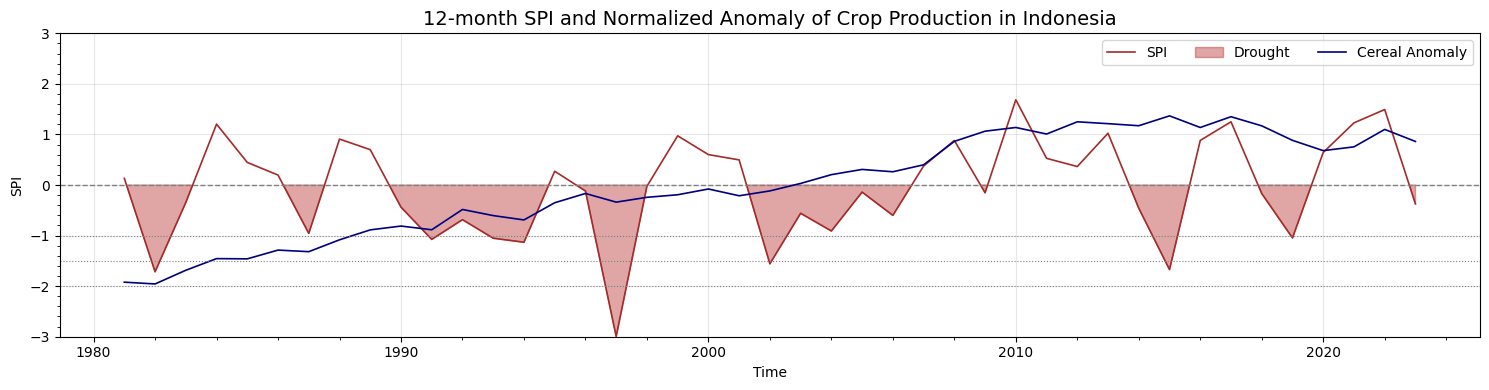

In [300]:
fig, ax = plt.subplots(figsize=(15,4))

# Serie SPI
ax.plot(annual_spi_indonesia.index, annual_spi_indonesia.spi, color='brown', lw=1.2, label='SPI')

# Línea de referencia
ax.axhline(0, color='gray', linestyle='--', lw=1)

# Sombrear sequía (SPI < 0)
ax.fill_between(
    annual_spi_indonesia.index,
    annual_spi_indonesia.spi,
    0,
    where=(annual_spi_indonesia.spi < 0),
    interpolate=True,
    color='firebrick',
    alpha=0.4,
    label='Drought'
)

data = cereal_land_long_VI[cereal_land_long_VI['Country Name'] == 'Indonesia']
# Use data_years_datetime for plotting the cereal anomaly
ax.plot(data.Year, data['Anomaly_Normalized'], color = 'navy', linewidth=1.2, label='Cereal Anomaly')

# Formato
ax.set_title('12-month SPI and Normalized Anomaly of Crop Production in Indonesia', fontsize=14)
ax.set_xlabel("Time")
ax.set_ylabel("SPI")
ax.set_ylim(-3, 3)

# Líneas horizontales de referencia
ax.axhline(-1.0, color='gray', ls=':', lw=0.8)
ax.axhline(-1.5, color='gray', ls=':', lw=0.8)
ax.axhline(-2.0, color='gray', ls=':', lw=0.8)

ax.grid(alpha=0.3)
ax.minorticks_on()
ax.legend(loc='upper right', ncol=4, frameon=True)

plt.tight_layout()
plt.show()

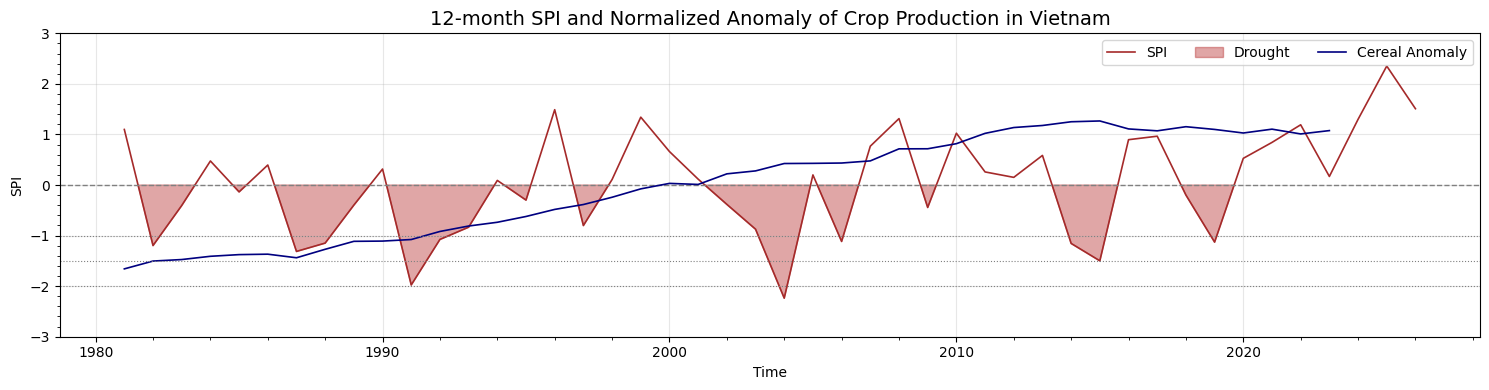

In [301]:
fig, ax = plt.subplots(figsize=(15,4))

# Serie SPI
ax.plot(annual_spi_viet.index, annual_spi_viet.spi, color='brown', lw=1.2, label='SPI')

# Línea de referencia
ax.axhline(0, color='gray', linestyle='--', lw=1)

# Sombrear sequía (SPI < 0)
ax.fill_between(
    annual_spi_viet.index,
    annual_spi_viet.spi,
    0,
    where=(annual_spi_viet.spi < 0),
    interpolate=True,
    color='firebrick',
    alpha=0.4,
    label='Drought'
)

data = cereal_land_long_VI[cereal_land_long_VI['Country Name'] == 'Viet Nam']
# Use data_years_datetime for plotting the cereal anomaly
ax.plot(data.Year, data['Anomaly_Normalized'], color = 'navy', linewidth=1.2, label='Cereal Anomaly')

# Formato
ax.set_title('12-month SPI and Normalized Anomaly of Crop Production in Vietnam', fontsize=14)
ax.set_xlabel("Time")
ax.set_ylabel("SPI")
ax.set_ylim(-3, 3)

# Líneas horizontales de referencia
ax.axhline(-1.0, color='gray', ls=':', lw=0.8)
ax.axhline(-1.5, color='gray', ls=':', lw=0.8)
ax.axhline(-2.0, color='gray', ls=':', lw=0.8)

ax.grid(alpha=0.3)
ax.minorticks_on()
ax.legend(loc='upper right', ncol=4, frameon=True)

plt.tight_layout()
plt.show()

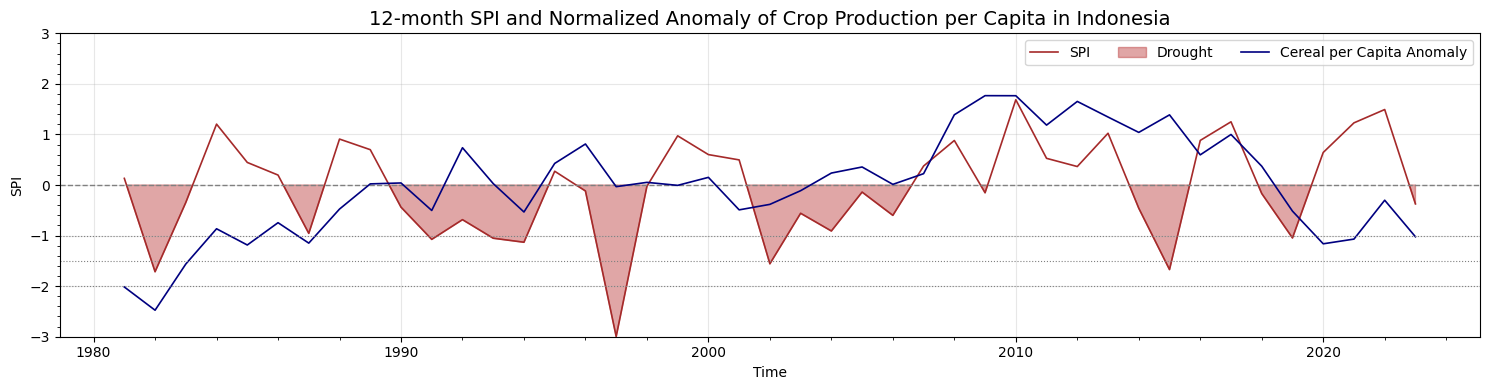

In [302]:

fig, ax = plt.subplots(figsize=(15,4))

# Serie SPI
ax.plot(annual_spi_indonesia.index, annual_spi_indonesia.spi, color='brown', lw=1.2, label='SPI')

# Línea de referencia
ax.axhline(0, color='gray', linestyle='--', lw=1)

# Sombrear sequía (SPI < 0)
ax.fill_between(
    annual_spi_indonesia.index,
    annual_spi_indonesia.spi,
    0,
    where=(annual_spi_indonesia.spi < 0),
    interpolate=True,
    color='firebrick',
    alpha=0.4,
    label='Drought'
)

data = merged_df[merged_df['Country Name'] == 'Indonesia']
# Use data_years_datetime for plotting the cereal anomaly
ax.plot(data.Year, data['Anomaly_Normalized'], color = 'navy', linewidth=1.2, label='Cereal per Capita Anomaly')

# Formato
ax.set_title('12-month SPI and Normalized Anomaly of Crop Production per Capita in Indonesia', fontsize=14)
ax.set_xlabel("Time")
ax.set_ylabel("SPI")
ax.set_ylim(-3, 3)

# Líneas horizontales de referencia
ax.axhline(-1.0, color='gray', ls=':', lw=0.8)
ax.axhline(-1.5, color='gray', ls=':', lw=0.8)
ax.axhline(-2.0, color='gray', ls=':', lw=0.8)

ax.grid(alpha=0.3)
ax.minorticks_on()
ax.legend(loc='upper right', ncol=4, frameon=True)

plt.tight_layout()
plt.show()

In [303]:
annual_spi_viet = annual_spi_viet.loc[annual_spi_viet.index <= 2023, :]

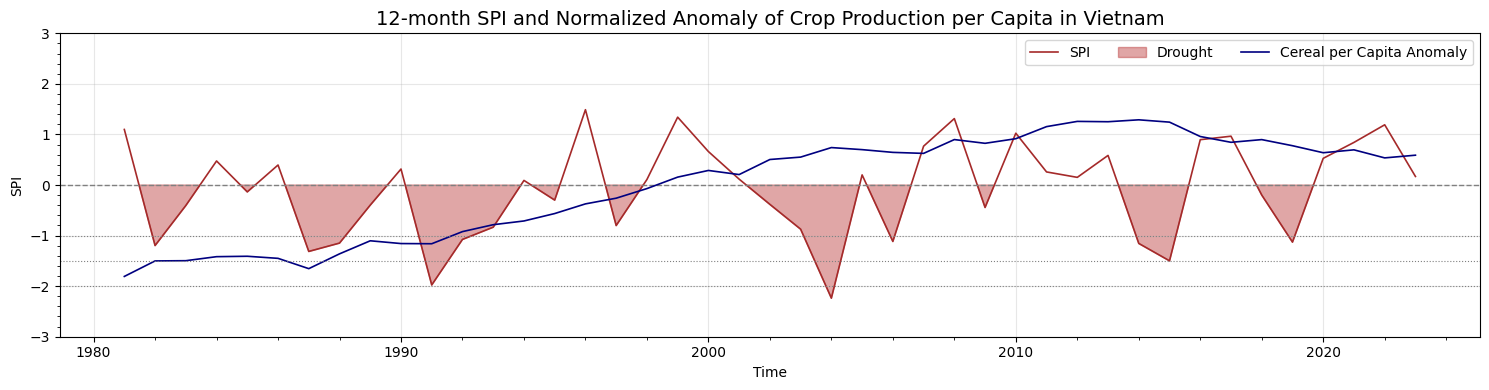

In [304]:
fig, ax = plt.subplots(figsize=(15,4))

# Serie SPI
ax.plot(annual_spi_viet.index, annual_spi_viet.spi, color='brown', lw=1.2, label='SPI')

# Línea de referencia
ax.axhline(0, color='gray', linestyle='--', lw=1)

# Sombrear sequía (SPI < 0)
ax.fill_between(
    annual_spi_viet.index,
    annual_spi_viet.spi,
    0,
    where=(annual_spi_viet.spi < 0),
    interpolate=True,
    color='firebrick',
    alpha=0.4,
    label='Drought'
)

data = merged_df[merged_df['Country Name'] == 'Viet Nam']
# Use data_years_datetime for plotting the cereal anomaly
ax.plot(data.Year, data['Anomaly_Normalized'], color = 'navy', linewidth=1.2, label='Cereal per Capita Anomaly')

# Formato
ax.set_title('12-month SPI and Normalized Anomaly of Crop Production per Capita in Vietnam', fontsize=14)
ax.set_xlabel("Time")
ax.set_ylabel("SPI")
ax.set_ylim(-3, 3)

# Líneas horizontales de referencia
ax.axhline(-1.0, color='gray', ls=':', lw=0.8)
ax.axhline(-1.5, color='gray', ls=':', lw=0.8)
ax.axhline(-2.0, color='gray', ls=':', lw=0.8)

ax.grid(alpha=0.3)
ax.minorticks_on()
ax.legend(loc='upper right', ncol=4, frameon=True)

plt.tight_layout()
plt.show()

In [305]:
## Use the de-trended data

## Use the de-trended data


In [306]:
path_gd

'/content/drive/MyDrive/Group Project Folder/Data/'

In [307]:
path_gd

'/content/drive/MyDrive/Group Project Folder/Data/'

In [308]:
detrended = pd.read_csv(path_gd + 'detrended_normalized_anomaly_cerial_data.csv')

In [309]:
detrended.head()

,Country Name,Country Code,Year,Production,detrended,detrended_Mean,Anomaly,detrended_Std,Anomaly_Normalized
0,Indonesia,IDN,1981,37283478.0,-1.433609e+06,4.851541e-09,-1.433609e+06,2.158616e+06,-0.664133
1,Viet Nam,VNM,1981,12844800.0,1.973415e+06,1.433804e-08,1.973415e+06,1.203843e+06,1.639262
2,Indonesia,IDN,1982,36818521.0,-3.127823e+06,4.851541e-09,-3.127823e+06,2.158616e+06,-1.448995
3,Viet Nam,VNM,1982,14828300.0,2.774720e+06,1.433804e-08,2.774720e+06,1.203843e+06,2.304885
4,Indonesia,IDN,1983,40389883.0,-7.857188e+05,4.851541e-09,-7.857188e+05,2.158616e+06,-0.363992


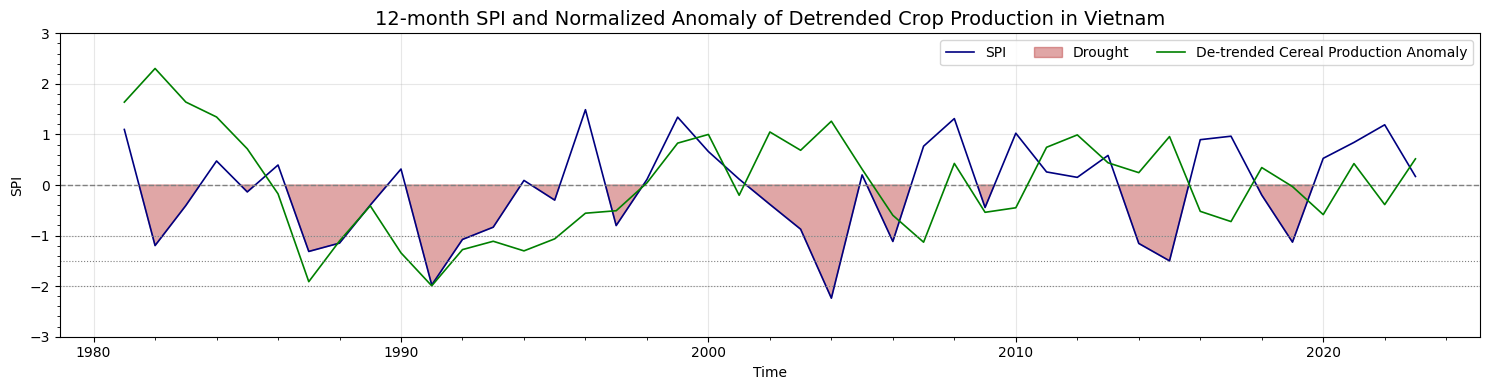

In [313]:
fig, ax = plt.subplots(figsize=(15,4))

# Serie SPI
ax.plot(annual_spi_viet.index, annual_spi_viet.spi, color='navy', lw=1.2, label='SPI')

# Línea de referencia
ax.axhline(0, color='gray', linestyle='--', lw=1)

# Sombrear sequía (SPI < 0)
ax.fill_between(
    annual_spi_viet.index,
    annual_spi_viet.spi,
    0,
    where=(annual_spi_viet.spi < 0),
    interpolate=True,
    color='firebrick',
    alpha=0.4,
    label='Drought'
)

data = detrended[detrended['Country Name'] == 'Viet Nam']
# Use data_years_datetime for plotting the cereal anomaly
ax.plot(data.Year, data['Anomaly_Normalized'], color = 'green', linewidth=1.2, label='De-trended Cereal Production Anomaly')

# Formato
ax.set_title('12-month SPI and Normalized Anomaly of Detrended Crop Production in Vietnam', fontsize=14)
ax.set_xlabel("Time")
ax.set_ylabel("SPI")
ax.set_ylim(-3, 3)

# Líneas horizontales de referencia
ax.axhline(-1.0, color='gray', ls=':', lw=0.8)
ax.axhline(-1.5, color='gray', ls=':', lw=0.8)
ax.axhline(-2.0, color='gray', ls=':', lw=0.8)

ax.grid(alpha=0.3)
ax.minorticks_on()
ax.legend(loc='upper right', ncol=4, frameon=True)

plt.tight_layout()
plt.show()

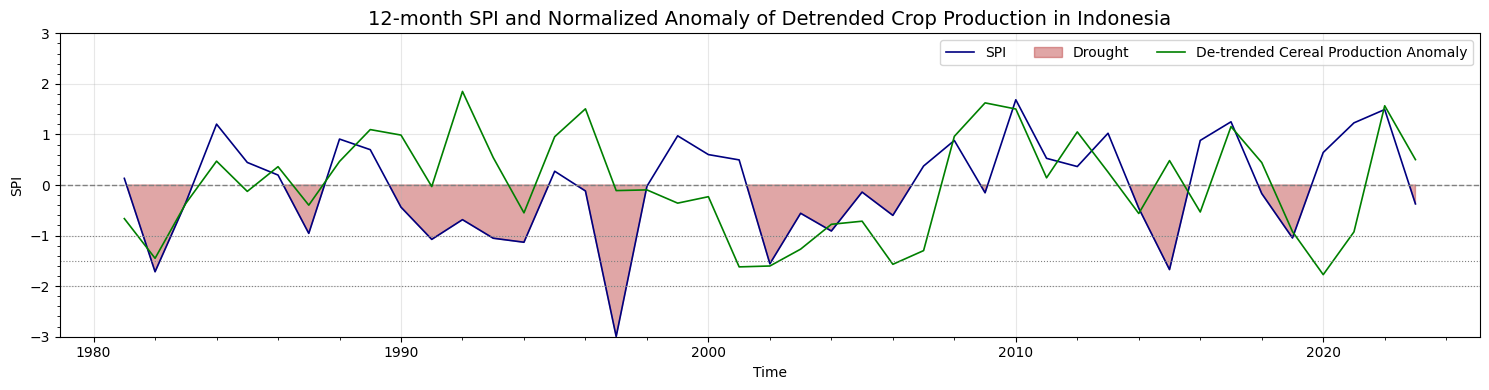

In [314]:
fig, ax = plt.subplots(figsize=(15,4))

# Serie SPI
ax.plot(annual_spi_indonesia.index, annual_spi_indonesia.spi, color='navy', lw=1.2, label='SPI')

# Línea de referencia
ax.axhline(0, color='gray', linestyle='--', lw=1)

# Sombrear sequía (SPI < 0)
ax.fill_between(
    annual_spi_indonesia.index,
    annual_spi_indonesia.spi,
    0,
    where=(annual_spi_indonesia.spi < 0),
    interpolate=True,
    color='firebrick',
    alpha=0.4,
    label='Drought'
)

data = detrended[detrended['Country Name'] == 'Indonesia']
# Use data_years_datetime for plotting the cereal anomaly
ax.plot(data.Year, data['Anomaly_Normalized'], color = 'green', linewidth=1.2, label='De-trended Cereal Production Anomaly')

# Formato
ax.set_title('12-month SPI and Normalized Anomaly of Detrended Crop Production in Indonesia', fontsize=14)
ax.set_xlabel("Time")
ax.set_ylabel("SPI")
ax.set_ylim(-3, 3)

# Líneas horizontales de referencia
ax.axhline(-1.0, color='gray', ls=':', lw=0.8)
ax.axhline(-1.5, color='gray', ls=':', lw=0.8)
ax.axhline(-2.0, color='gray', ls=':', lw=0.8)

ax.grid(alpha=0.3)
ax.minorticks_on()
ax.legend(loc='upper right', ncol=4, frameon=True)

plt.tight_layout()
plt.show()